#📌 Extracción

In [8]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
respuesta = requests.get(url)
datos = respuesta.json()
df = pd.json_normalize(datos)

print("Extaidos")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Extaidos
Filas: 7267, Columnas: 21


#🔧 Transformación

In [2]:
print("Valores únicos en Churn:")
for valor in df['Churn'].unique():
    print(repr(valor))

print("\nConteo:")
print(df['Churn'].value_counts(dropna=False))

Valores únicos en Churn:
'No'
'Yes'
''

Conteo:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [3]:
df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()
df = df[df['Churn'].isin(['yes', 'no'])]
df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})

print("Churn limpio")
print(df['Churn'].value_counts())
print(f"\nFilas restantes: {len(df)}")

Churn limpio
Churn
0    5174
1    1869
Name: count, dtype: int64

Filas restantes: 7043


In [4]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
nulos = df['account.Charges.Total'].isnull().sum()
print(f"Valores nulos en Charges.Total: {nulos}")

mediana = df['account.Charges.Total'].median()
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(mediana)
print(f"Nulos rellenados con mediana: {mediana}")

Valores nulos en Charges.Total: 11
Nulos rellenados con mediana: 1397.475


In [5]:
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30
print("Columna Cuentas_Diarias creada")
df[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

Columna Cuentas_Diarias creada


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [6]:
print("Verificación")
print(f"Total clientes: {len(df)}")
print(f"\nChurn (0=No, 1=Sí):")
print(df['Churn'].value_counts())
tasa = df['Churn'].mean() * 100
print(f"\nTasa de evasión: {tasa:.2f}%")
print(f"\nValores nulos restantes:")
print(df.isnull().sum())

Verificación
Total clientes: 7043

Churn (0=No, 1=Sí):
Churn
0    5174
1    1869
Name: count, dtype: int64

Tasa de evasión: 26.54%

Valores nulos restantes:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
Cuentas_Diarias              0
dtype: int64


#📊 Carga y análisis

In [7]:
df.describe()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,32.371149,64.761692,2281.916928,2.158723
std,0.441561,0.368612,24.559481,30.090047,2265.270398,1.003002
min,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,9.000000,35.500000,402.225000,1.183333
50%,0.000000,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,55.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

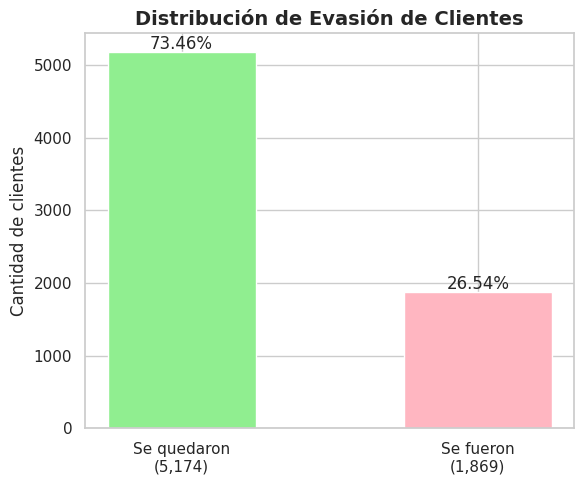

In [27]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

etiquetas = ['Se quedaron\n(5,174)', 'Se fueron\n(1,869)']
valores = [5174, 1869]
colores = ['lightgreen', 'lightpink']

plt.figure(figsize=(6,5))
plt.bar(etiquetas, valores, color=colores, edgecolor='white', width=0.5)
plt.title('Distribución de Evasión de Clientes', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de clientes')
plt.text(0, 5174 + 50, '73.46%', ha='center', fontsize=12)
plt.text(1, 1869 + 50, '26.54%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

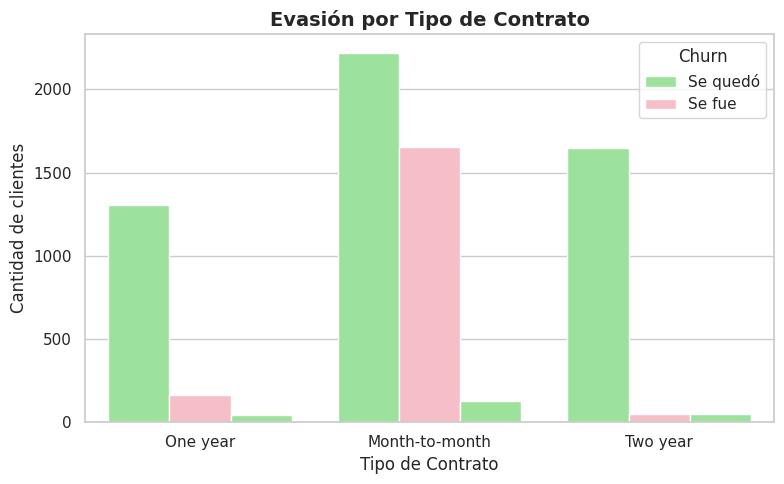

In [28]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='account.Contract', hue='Churn',
              palette=['lightgreen', 'lightpink'])
plt.title('Evasión por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Churn', labels=['Se quedó', 'Se fue'])
plt.tight_layout()
plt.show()

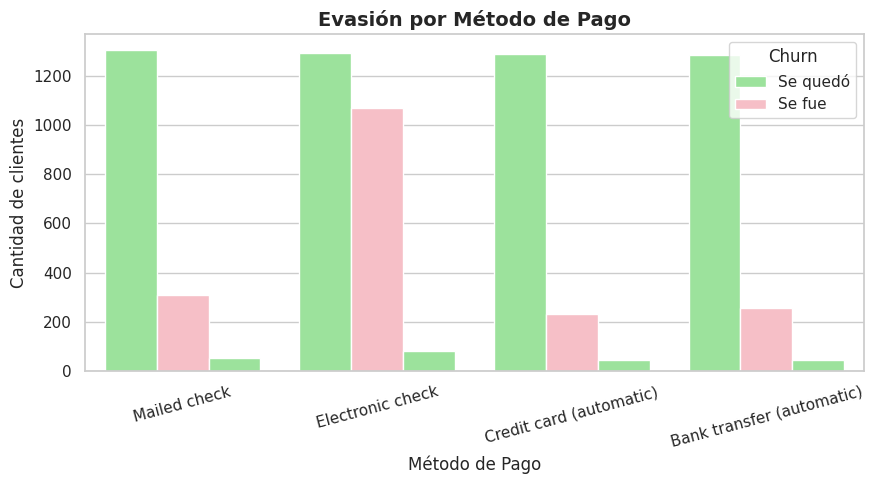

In [29]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='account.PaymentMethod', hue='Churn',
              palette=['lightgreen', 'lightpink'])
plt.title('Evasión por Método de Pago', fontsize=14, fontweight='bold')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=15)
plt.legend(title='Churn', labels=['Se quedó', 'Se fue'])
plt.tight_layout()
plt.show()

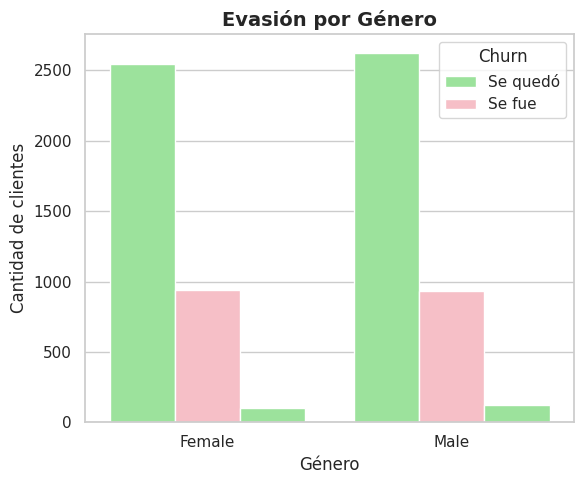

In [30]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='customer.gender', hue='Churn',
              palette=['lightgreen', 'lightpink'])
plt.title('Evasión por Género', fontsize=14, fontweight='bold')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Churn', labels=['Se quedó', 'Se fue'])
plt.tight_layout()
plt.show()

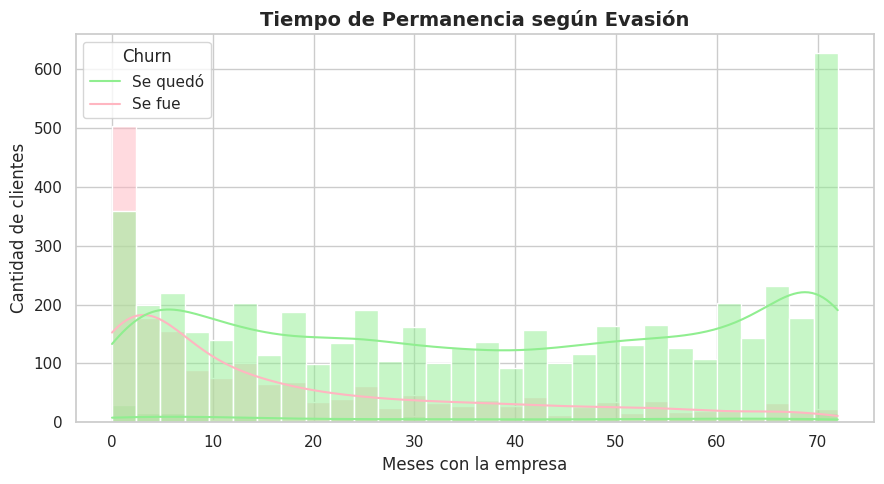

In [31]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(9,5))
sns.histplot(data=df, x='customer.tenure', hue='Churn',
             bins=30, kde=True, palette=['lightgreen', 'lightpink'])
plt.title('Tiempo de Permanencia según Evasión', fontsize=14, fontweight='bold')
plt.xlabel('Meses con la empresa')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Churn', labels=['Se quedó', 'Se fue'])
plt.tight_layout()
plt.show()

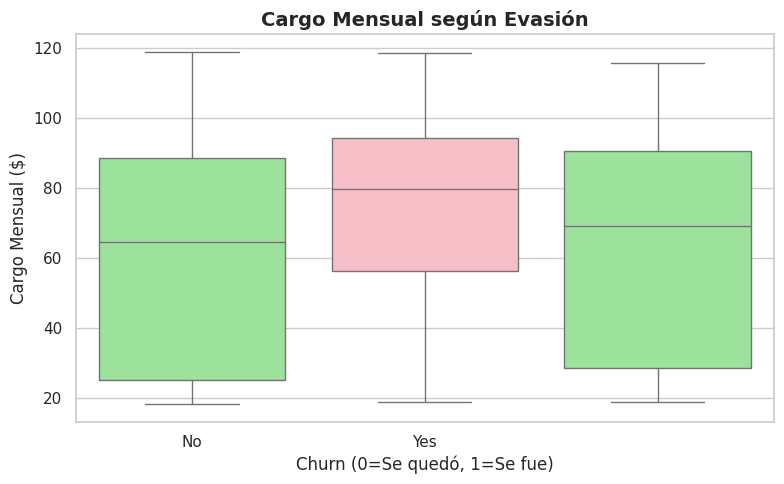

In [32]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='account.Charges.Monthly',
            hue='Churn', palette=['lightgreen', 'lightpink'], legend=False)
plt.title('Cargo Mensual según Evasión', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0=Se quedó, 1=Se fue)')
plt.ylabel('Cargo Mensual ($)')
plt.tight_layout()
plt.show()

#📄Informe final

#  Informe Final

## Introducción

¡Hola! Soy Giselle y este es mi análisis de evasión de clientes para Telecom X   
El objetivo fue entender por qué los clientes se van y qué patrones podemos encontrar
en los datos para ayudar a la empresa a retenerlos.

Trabajé con un dataset de **7,043 clientes** después de limpiar los datos,
y encontré cosas muy interesantes que comparto a continuación


## Limpieza de Datos

Antes de analizar, tuve que dejar los datos bien ordenados:

- Eliminé **224 filas** donde el valor de `Churn` estaba vacío, porque no podía
  saber si ese cliente se fue o se quedó.
- Convertí la columna `Charges.Total` a número, ya que estaba guardada como texto.
  Había **11 valores nulos** que rellené con la mediana ($1,397.47) para no perder
  esas filas.
- Creé la columna `Cuentas_Diarias` dividiendo el cargo mensual entre 30,
  para tener una perspectiva más granular del gasto diario por cliente.

Al final quedé con un dataset limpio de **7,043 clientes y 22 columnas**


## Análisis Exploratorio

### Tasa de Evasión General
De los 7,043 clientes, **1,869 se fueron** — eso es el **26.54%**.
¡Casi 1 de cada 4 clientes cancela! Eso es bastante alto y definitivamente
algo que Telecom X debería atender

### Evasión por Tipo de Contrato
Este fue uno de los hallazgos que más me llamó la atención.
Los clientes con contrato **mes a mes** se van mucho más que los que tienen
contrato a 1 o 2 años. Tiene sentido: si no tienes un compromiso largo,
es más fácil cancelar cuando algo no te gusta.

### Evasión por Método de Pago
Los clientes que pagan con **cheque electrónico** muestran una tasa de evasión
más alta comparados con los que usan pago automático (tarjeta o transferencia).
Esto podría indicar que los clientes con pago automático se "olvidan" de cancelar,
o simplemente están más comprometidos con el servicio.

### Evasión por Género
No encontré diferencias significativas entre hombres y mujeres en cuanto a evasión.
El género no parece ser un factor determinante aquí

### Tiempo de Permanencia (Tenure)
Los clientes que se van tienen un tiempo de permanencia mucho más bajo.
La mayoría cancela en los **primeros meses**. Esto me dice que el periodo
más crítico para retener a un cliente es justo al inicio de su contrato.
Si los primeros meses son una buena experiencia, es más probable que se queden.

### Cargo Mensual
Los clientes que cancelan pagan en promedio **más caro por mes** que los que
se quedan. Quizás sienten que el servicio no vale lo que están pagando


## Conclusiones

Después de todo este análisis, puedo concluir que los clientes con mayor
riesgo de evasión tienen este perfil:

- Contrato **mes a mes**
- Pago con **cheque electrónico**
- Pocos meses en la empresa (**tenure bajo**)
- **Cargo mensual alto**



## Recomendaciones

Con base en lo que encontré, le recomendaría a Telecom X:

1. **Incentivar contratos anuales** — ofrecer descuentos o beneficios a clientes
   que elijan planes de 1 o 2 años, ya que estos clientes tienen mucho menor
   probabilidad de cancelar.

2. **Programa de bienvenida reforzado** — los primeros meses son críticos.
   Un seguimiento personalizado al inicio puede marcar la diferencia entre
   que el cliente se quede o se vaya.

3. **Revisar la percepción de valor** — los clientes que pagan más son los que
   más cancelan. Vale la pena investigar si están recibiendo los beneficios
   que esperan por ese precio.

4. **Promover el pago automático** — migrar a los clientes de cheque electrónico
   a métodos de pago automático podría reducir la evasión pasiva.


## Reflexión Personal

Este fue mi primer proyecto de análisis de datos completo y aprendí muchísimo
en el camino desde limpiar datos con pandas hasta hacer gráficas con seaborn.
Hubo errores y frustraciones, pero cada bug resuelto se sintió como una pequeña
victoria

Sé que aún me falta mucho por aprender, pero este proyecto me emocionó bastante
y me confirmó que el análisis de datos es lo que quiero hacer.

¡Gracias por leer hasta aquí!

*— Giselle, estudiante de Data Science | Alura x Oracle Next ONE*